In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 64.3 MB/s eta 0:00:00


In [2]:
import gensim
import pprint
from gensim import corpora
from gensim.utils import simple_preprocess

documents = [
    "I love Python",
    "I love ccnlp",
    "Python is amazing"
]

doc_tokenize = [simple_preprocess(doc) for doc in documents]
print(doc_tokenize)
dictionary = corpora.Dictionary(doc_tokenize)
bow = [dictionary.doc2bow(doc) for doc in doc_tokenize]

print(bow)
new_dictionary = corpora.Dictionary.from_corpus(bow)

print("New Dictionary:", new_dictionary.token2id)

[['love', 'python'], ['love', 'ccnlp'], ['python', 'is', 'amazing']]
[[(0, 1), (1, 1)], [(0, 1), (2, 1)], [(1, 1), (3, 1), (4, 1)]]
New Dictionary: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4}


In [3]:
import nltk
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [4]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
sentence="I Love Natural Language Processing"
token= word_tokenize(sentence)
word=list(ngrams(token,1))
print(word)

[('I',), ('Love',), ('Natural',), ('Language',), ('Processing',)]


In [5]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
sentence="I Love Natural Language Processing"
token= word_tokenize(sentence)
word=list(ngrams(token,2))
print(word)

[('I', 'Love'), ('Love', 'Natural'), ('Natural', 'Language'), ('Language', 'Processing')]


In [6]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
sentence="I Love Natural Language Processing"
token= word_tokenize(sentence)
word=list(ngrams(token,3))
print(word)

[('I', 'Love', 'Natural'), ('Love', 'Natural', 'Language'), ('Natural', 'Language', 'Processing')]


In [7]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
sentence="I Love Natural Language Processing"
token= word_tokenize(sentence)
word=list(ngrams(token,4))
print(word)

[('I', 'Love', 'Natural', 'Language'), ('Love', 'Natural', 'Language', 'Processing')]


In [8]:
from nltk.util import ngrams
from nltk.tokenize import word_tokenize
sentence="I Love Natural Language Processing"
token= word_tokenize(sentence)
word=list(ngrams(token,5))
print(word)

[('I', 'Love', 'Natural', 'Language', 'Processing')]


In [9]:
from collections import defaultdict, Counter

def next_word_probability(sentences, word):
    model = defaultdict(list)

    for sentence in sentences:
        words = sentence.lower().split()
        for i in range(len(words)-1):
            model[words[i]].append(words[i+1])

    count = Counter(model[word.lower()])
    total = sum(count.values())

    for w in count:
        print(f"P({w} | {word}) = {count[w]/total:.2f}")


corpus = [
    "I like python",
    "I like java",
    "I like python programming"
]


next_word_probability(corpus, "python")

P(programming | python) = 1.00


In [10]:
from gensim.models import Phrases

sentences = [
    ["machine","learning"],
    ["machine","learning"],
    ["deep","learning"]
]

bigram = Phrases(sentences, min_count=1)

print(bigram[sentences[0]])

['machine', 'learning']


In [11]:
from gensim.corpora import Dictionary

docs = [
    ["python", "java"],
    ["python", "c++"],
    ["python", "go"]
]

dictionary = Dictionary(docs)

print("Before:")
print(dictionary.token2id)

dictionary.filter_extremes(no_below=2)

print("After:")
print(dictionary.token2id)

Before:
{'java': 0, 'python': 1, 'c++': 2, 'go': 3}
After:
{}


In [12]:
from gensim.corpora import Dictionary

docs = [
    ["python", "java"],
    ["python", "c++"]
]

dictionary = Dictionary(docs)

doc = ["python", "java", "python"]

print(dictionary.doc2idx(doc))

[1, 0, 1]


In [13]:
from gensim.corpora import Dictionary

dict1 = Dictionary([["python", "java"]])

dict2 = Dictionary([["java", "c++"]])

dict1.merge_with(dict2)

print(dict1.token2id)

{'java': 0, 'python': 1, 'c++': 2}


In [14]:
from gensim.corpora import Dictionary

docs = [
    ["python", "java"],
    ["python", "c++"]
]

dictionary = Dictionary(docs)

dictionary.save("mydict.dict")

new_dict = Dictionary.load("mydict.dict")

print(new_dict.token2id)

{'java': 0, 'python': 1, 'c++': 2}


In [15]:
from gensim.corpora import Dictionary

docs = [
    ["python", "java"],
    ["python", "c++"]
]

dictionary = Dictionary(docs)

print(dictionary.token2id)

{'java': 0, 'python': 1, 'c++': 2}


**Festivals**

In [16]:
import gensim.downloader as api

keywords = ["india", "indian", "culture", "festival", "food",
            "ritual", "tradition", "saint", "scripture", "religion"]

for corpus in api.info()["corpora"]:
    if any(word in corpus.lower() for word in keywords):
        print(corpus)

In [17]:
import nltk

downloader = nltk.downloader.Downloader()

keywords = ["india", "indian", "culture", "festival", "food",
            "ritual", "tradition", "saint", "scripture", "religion"]

found = False

for package in downloader.packages():
    if package.subdir == "corpora":
        if any(word in package.id.lower() for word in keywords):
            print(package.id)
            found = True

if not found:
    print("No matching corpus found.")

indian


In [18]:

import nltk
nltk.download('indian')


[nltk_data] Downloading package indian to /root/nltk_data...
[nltk_data]   Unzipping corpora/indian.zip.


True

In [19]:

from nltk.corpus import indian

print(indian.fileids())

['bangla.pos', 'hindi.pos', 'marathi.pos', 'telugu.pos']


In [20]:
!pip install requests beautifulsoup4

In [21]:
import requests
from bs4 import BeautifulSoup

urls = [
    "https://www.bbc.com/hindi",
    "https://www.bbc.com/hindi/topics/cq23pdgvz8rt",
    "https://www.bbc.com/hindi/topics/cyx5krnw38vt"
]

headers = {
    "User-Agent": "Mozilla/5.0"
}

corpus = ""

for url in urls:
    print(f"\nScraping: {url}")

    try:
        response = requests.get(url, headers=headers, timeout=10)

        print("Status Code:", response.status_code)

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, "html.parser")

            paragraphs = soup.find_all("p")

            for p in paragraphs:
                text = p.get_text(" ", strip=True)

                if text:
                    corpus += text + "\n"

        else:
            print(f"Failed to fetch: {url}")

    except Exception as e:
        print(f"Error: {e}")

print("\nCorpus Preview:\n")
print(corpus[:1000])

print(f"\nTotal Characters: {len(corpus)}")


Scraping: https://www.bbc.com/hindi
Status Code: 200

Scraping: https://www.bbc.com/hindi/topics/cq23pdgvz8rt
Status Code: 404
Failed to fetch: https://www.bbc.com/hindi/topics/cq23pdgvz8rt

Scraping: https://www.bbc.com/hindi/topics/cyx5krnw38vt
Status Code: 404
Failed to fetch: https://www.bbc.com/hindi/topics/cyx5krnw38vt

Corpus Preview:

लॉग इन करें या निःशुल्क नया खाता बनाएं
या
भारत में अमेरिका के राजदूत सर्जियो गोर ने जम्मू-कश्मीर का दौरा किया है और मुख्यमंत्री उमर अब्दुल्ला से मुलाक़ात की है.
समाचार एजेंसी पीटीआई के मुताबिक़, ये हादसा तब हुआ जब एक ट्रक में सीएनजी भरी जा रही थी. पंप का कर्मचारी एक ट्रक में सीएनजी भर रहा था. इसी दौरान उसके सिलेंडर में ब्लास्ट हो गया.
भारत ‘शहज़ाद भट्टी नेटवर्क’ के ख़िलाफ़ कार्रवाई कर रहा है और उस पर आईएसआई से संबंध होने का आरोप लगा रहा है. शहज़ाद भट्टी कौन है और भारत का उस पर क्या आरोप है?
अप्रैल में हुए विधानसभा चुनाव के दौरान शिवसागर में मियां मुसलमानों का विरोध करने वाले होर्डिंग लगाए गए थे. इनमें से कुछ होर्डिंग अब भी दिखाई दे रहे हैं. लेकिन

In [22]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [23]:
from nltk.tokenize import word_tokenize
import nltk
tokens = word_tokenize(corpus)
print(tokens[:20])

['लॉग', 'इन', 'करें', 'या', 'निःशुल्क', 'नया', 'खाता', 'बनाएं', 'या', 'भारत', 'में', 'अमेरिका', 'के', 'राजदूत', 'सर्जियो', 'गोर', 'ने', 'जम्मू-कश्मीर', 'का', 'दौरा']


In [24]:
from nltk import FreqDist

bow = FreqDist(tokens)
print(bow.most_common(20))

[('के', 59), ('.', 59), ('की', 38), ('में', 36), ('से', 29), ('है', 28), ('और', 22), ('को', 21), ('का', 20), ('ने', 17), ('पर', 17), ('हैं', 17), (',', 14), ('भारत', 12), ('था', 10), ('लिए', 10), ('एक', 9), ('इस', 9), ('गया', 8), ('भी', 8)]


In [25]:
!apt-get update
!apt-get install -y fonts-noto-core

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [110 kB]
Get:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,202 kB]
Hit:10 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:11 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1,314 kB]
Get:12 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [7,569 kB

In [26]:
import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)

In [27]:
import matplotlib.font_manager as fm

fonts = sorted(set(f.name for f in fm.fontManager.ttflist))
print(fonts)

['DejaVu Sans', 'DejaVu Sans Display', 'DejaVu Sans Mono', 'DejaVu Serif', 'DejaVu Serif Display', 'Humor Sans', 'Liberation Mono', 'Liberation Sans', 'Liberation Sans Narrow', 'Liberation Serif', 'STIXGeneral', 'STIXNonUnicode', 'STIXSizeFiveSym', 'STIXSizeFourSym', 'STIXSizeOneSym', 'STIXSizeThreeSym', 'STIXSizeTwoSym', 'cmb10', 'cmex10', 'cmmi10', 'cmr10', 'cmss10', 'cmsy10', 'cmtt10']


In [28]:
!apt-get update -qq
!apt-get install -y fonts-noto-core

import matplotlib.font_manager as fm

fm._load_fontmanager(try_read_cache=False)

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
fonts-noto-core is already the newest version (20201225-1build1).
0 upgraded, 0 newly installed, 0 to remove and 34 not upgraded.


In [29]:
import os

for root, dirs, files in os.walk("/usr/share/fonts"):
    for file in files:
        if "Devanagari" in file and file.endswith((".ttf", ".otf")):
            print(os.path.join(root, file))

/usr/share/fonts/truetype/noto/NotoSansDevanagari-Bold.ttf
/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf
/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Bold.ttf
/usr/share/fonts/truetype/noto/NotoSerifDevanagari-Regular.ttf


/tmp/ipykernel_470/2253897964.py:21: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_470/2253897964.py:21: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  fig.canvas.print_figure(bytes_io, **kw)


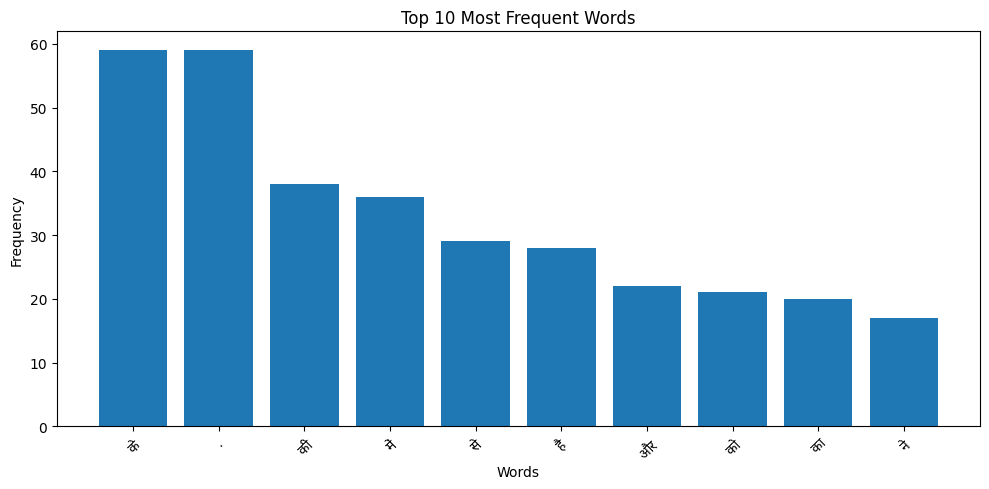

In [30]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

font_path = "/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf"

prop = fm.FontProperties(fname=font_path)

top_words = bow.most_common(10)

words = [w for w, f in top_words]
counts = [f for w, f in top_words]

plt.figure(figsize=(10, 5))
plt.bar(words, counts)

plt.xticks(rotation=45, fontproperties=prop)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 10 Most Frequent Words")

plt.tight_layout()
plt.show()

In [31]:
from nltk.util import ngrams
from nltk import FreqDist

bigrams = list(ngrams(tokens, 2))

bigram_freq = FreqDist(bigrams)

print(bigram_freq.most_common(10))

[(('है', '.'), 16), (('हैं', '.'), 12), (('के', 'लिए'), 10), (('था', '.'), 8), (('रहे', 'हैं'), 6), (('रहा', 'है'), 4), (('के', 'दौरान'), 4), (('है', 'कि'), 4), (('गया', 'था'), 4), (('पाकिस्तान', 'के'), 4)]


In [32]:
trigrams = list(ngrams(tokens, 3))

trigram_freq = FreqDist(trigrams)

print(trigram_freq.most_common(10))

[(('रहे', 'हैं', '.'), 4), (('की', 'है', '.'), 3), (('गया', 'था', '.'), 3), (('की', 'वजह', 'से'), 3), (('एक', 'ट्रक', 'में'), 2), (('ट्रक', 'में', 'सीएनजी'), 2), (('हो', 'गया', '.'), 2), (('रहा', 'है', '.'), 2), (('हैं', '.', 'लेकिन'), 2), (('किया', 'था', '.'), 2)]


/tmp/ipykernel_470/1685369457.py:17: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_470/1685369457.py:17: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()


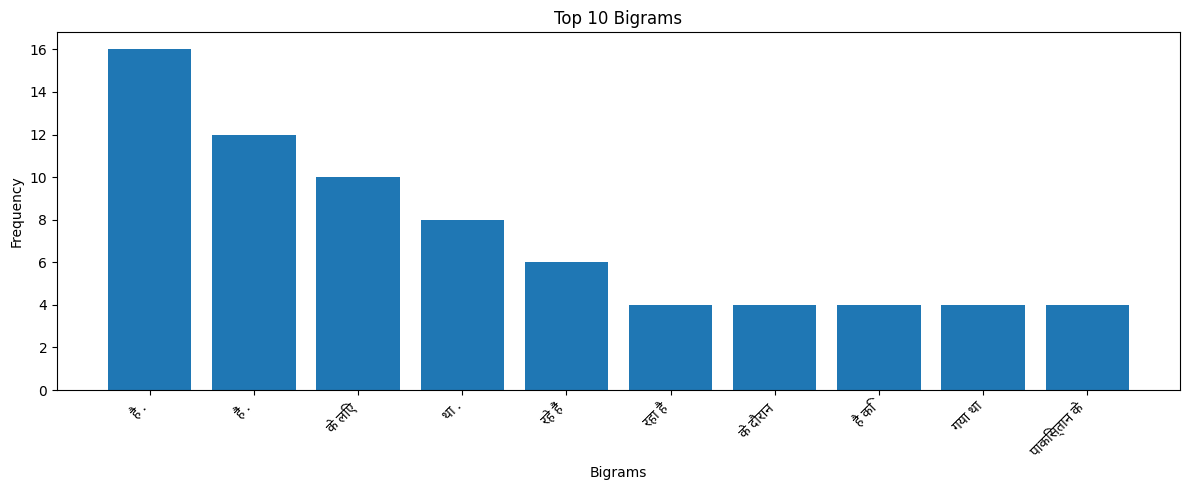

In [33]:
import matplotlib.pyplot as plt

top_bigrams = bigram_freq.most_common(10)

bigrams = [" ".join(bg) for bg, freq in top_bigrams]
counts = [freq for bg, freq in top_bigrams]

plt.figure(figsize=(12,5))
plt.bar(bigrams, counts)

plt.title("Top 10 Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")

plt.xticks(rotation=45, ha="right", fontproperties=prop)

plt.tight_layout()
plt.show()

In [34]:
import requests
from bs4 import BeautifulSoup

urls = {
    "Diwali": "https://www.rudraksha-ratna.com/articles/diwali-festival",
    "Holi": "https://utsav.gov.in/major-festival/holi",
    "Navratri": "https://utsav.gov.in/major-festival/navratri"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

corpus = ""

for festival, url in urls.items():

    print(f"\nScraping: {festival}")

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=30
        )

        print("Status Code:", response.status_code)

        if response.status_code == 200:

            soup = BeautifulSoup(
                response.text,
                "html.parser"
            )

            festival_text = ""

            for p in soup.find_all("p"):
                text = p.get_text(" ", strip=True)

                if text:
                    festival_text += text + "\n"

            corpus += f"\n===== {festival} =====\n"
            corpus += festival_text

            print("Characters collected:", len(festival_text))

        else:
            print(f"Failed to fetch: {festival}")

    except requests.exceptions.RequestException as e:
        print(f"Error scraping {festival}: {e}")


print("\n===== CORPUS PREVIEW =====\n")
print(corpus[:2000])

print("\nTotal Characters:", len(corpus))


Scraping: Diwali
Status Code: 200
Characters collected: 30540

Scraping: Holi
Status Code: 200
Characters collected: 2877

Scraping: Navratri
Status Code: 200
Characters collected: 3942

===== CORPUS PREVIEW =====


===== Diwali =====
Worldwide Fast & Safe Delivery | Oldest ISO 9001-2015 Certified Rudraksha Organization in the World | Your Trusted Brand Since 1997
More
Brand Info
More
Brand Info
Are you sure you want to logout?
Shopping Cart
You have no items in your cart. Please, click here to continue shopping.
Are you sure you want to remove this product?
Login
OR
You can also:
Categories
Table of Contents
Diwali, also referred to as the Festival of Lights, is one of the most important and widely celebrated festivals in India.  This energetic celebration of 5 days' festivities stands for wisdom over ignorance, Good over Evil, and Light over Darkness. Diwali is observed with great fervor all throughout the nation as Shri Ram returns to Ayodhya following 14 years of exile and triumph

In [35]:
from bs4 import BeautifulSoup
import re

# Remove extra spaces and newlines
clean_corpus = re.sub(r'\s+', ' ', corpus)

# Remove unwanted website text
unwanted_text = [
    "Worldwide Fast & Safe Delivery",
    "Shopping Cart",
    "You have no items in your cart",
    "Please, click here to continue shopping",
    "Are you sure you want to logout?",
    "Login OR You can also:",
    "Categories",
    "Table of Contents"
]

for text in unwanted_text:
    clean_corpus = clean_corpus.replace(text, "")

print("===== CLEAN CORPUS PREVIEW =====\n")
print(clean_corpus[:2000])

print("\nTotal Clean Characters:", len(clean_corpus))

===== CLEAN CORPUS PREVIEW =====

 ===== Diwali =====  | Oldest ISO 9001-2015 Certified Rudraksha Organization in the World | Your Trusted Brand Since 1997 More Brand Info More Brand Info   . . Are you sure you want to remove this product?    Diwali, also referred to as the Festival of Lights, is one of the most important and widely celebrated festivals in India. This energetic celebration of 5 days' festivities stands for wisdom over ignorance, Good over Evil, and Light over Darkness. Diwali is observed with great fervor all throughout the nation as Shri Ram returns to Ayodhya following 14 years of exile and triumphs over the Evil Asura King Ravana. Oil lamps, candles, and vibrant rangoli cover homes and streets; the smells of mouthwatering sweets permeate the air as fireworks blast skyward. Diwali is not just a religious festival but also a celebration of family unity, gift-giving, love and friendship rejuvenation. Diwali begins with Dhanteras and ends with Bhai Dooj Puja, in which D

In [36]:
festivals = {
    "Diwali": {
        "mr": "दिवाळी"
    },
    "Holi": {
        "mr": "होळी"
    },
    "Navratri": {
        "mr": "नवरात्री"
    }
}

for festival, languages in festivals.items():
    print(festival)

    for lang, name in languages.items():
        if lang == "mr":
            print(lang, "->", name)

Diwali
mr -> दिवाळी
Holi
mr -> होळी
Navratri
mr -> नवरात्री


In [37]:
import requests
from bs4 import BeautifulSoup

urls = {
    "Diwali_Marathi": "https://maharashtratourism.gov.in/mr/festivals/%E0%A4%A6%E0%A4%BF%E0%A4%B5%E0%A4%BE%E0%A4%B3%E0%A5%80/"
}

headers = {
    "User-Agent": "Mozilla/5.0"
}

marathi_corpus = ""

for festival, url in urls.items():

    print(f"\nScraping: {festival}")

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=30
        )

        print("Status Code:", response.status_code)

        if response.status_code == 200:

            soup = BeautifulSoup(response.text, "html.parser")

            festival_text = ""

            for p in soup.find_all("p"):
                text = p.get_text(" ", strip=True)

                if text:
                    festival_text += text + "\n"

            marathi_corpus += f"\n===== {festival} =====\n"
            marathi_corpus += festival_text

            print("Characters collected:", len(festival_text))

        else:
            print("Failed to fetch")

    except requests.exceptions.RequestException as e:
        print("Error:", e)


print("\n===== MARATHI CORPUS PREVIEW =====\n")
print(marathi_corpus[:2000])

print("\nTotal Characters:", len(marathi_corpus))


Scraping: Diwali_Marathi
Status Code: 200
Characters collected: 4192

===== MARATHI CORPUS PREVIEW =====


===== Diwali_Marathi =====
Skip to Content
म En English म मराठी
म En English म मराठी
Skip to Content
म En English म मराठी
म En English म मराठी
दिवाळी हा भारतातील सर्वाधिक साजरा केला जाणारा आणि सर्वांत महत्त्वाचा सण आहे. प्रकाशाचा सण म्हणून ओळखला जाणारा दिवाळी हा एक साधा उत्सव नाही, तर तो आनंद, एकता, आणि नात्यांचा उत्सव आहे. हा सण अंधारावर प्रकाशाचा, अज्ञानावर ज्ञानाचा, आणि वाईटावर चांगुलपणाचा विजय साजरा करतो. महाराष्ट्रात दिवाळी हा सण फक्त धार्मिक नव्हे, तर सामाजिक आणि सांस्कृतिक दृष्टिकोनातूनही महत्त्वाचा आहे.
दिवाळी हा पाच दिवसांचा सण असून महाराष्ट्रापासून भारतासह जगभरात साजरा केला जातो. प्रत्येक दिवसाचे वेगळे धार्मिक, सांस्कृतिक आणि आध्यात्मिक महत्त्व आहे.
दिवाळीचा सण महाराष्ट्रामध्ये सुद्धा विविध परंपरांनुसार साजरा होतो. तो एक सण नसून पाचही दिवस निरनिराळ्या पद्धतीने आपापसातील नात्यांची जपणूक करण्याचा अनोखा उत्सव आहे.
दिवाळी हा सण प्राचीन काळाशी जोडलेला असून त्याला अनेक पौराणि

In [38]:
import re

# Remove repeated website navigation text
marathi_corpus = re.sub(
    r"Skip to Content.*?मराठी",
    "",
    marathi_corpus,
    count=1
)

# Remove extra whitespace
marathi_corpus = re.sub(r"\s+", " ", marathi_corpus)

print("===== CLEAN MARATHI CORPUS =====\n")
print(marathi_corpus[:2000])

print("\nTotal Characters:", len(marathi_corpus))

===== CLEAN MARATHI CORPUS =====

 ===== Diwali_Marathi ===== Skip to Content म En English म मराठी म En English म मराठी Skip to Content म En English म मराठी म En English म मराठी दिवाळी हा भारतातील सर्वाधिक साजरा केला जाणारा आणि सर्वांत महत्त्वाचा सण आहे. प्रकाशाचा सण म्हणून ओळखला जाणारा दिवाळी हा एक साधा उत्सव नाही, तर तो आनंद, एकता, आणि नात्यांचा उत्सव आहे. हा सण अंधारावर प्रकाशाचा, अज्ञानावर ज्ञानाचा, आणि वाईटावर चांगुलपणाचा विजय साजरा करतो. महाराष्ट्रात दिवाळी हा सण फक्त धार्मिक नव्हे, तर सामाजिक आणि सांस्कृतिक दृष्टिकोनातूनही महत्त्वाचा आहे. दिवाळी हा पाच दिवसांचा सण असून महाराष्ट्रापासून भारतासह जगभरात साजरा केला जातो. प्रत्येक दिवसाचे वेगळे धार्मिक, सांस्कृतिक आणि आध्यात्मिक महत्त्व आहे. दिवाळीचा सण महाराष्ट्रामध्ये सुद्धा विविध परंपरांनुसार साजरा होतो. तो एक सण नसून पाचही दिवस निरनिराळ्या पद्धतीने आपापसातील नात्यांची जपणूक करण्याचा अनोखा उत्सव आहे. दिवाळी हा सण प्राचीन काळाशी जोडलेला असून त्याला अनेक पौराणिक कथांचा आधार आहे. रामायणानुसार, भगवान श्रीराम, माता सीता, आणि लक्ष्मण या

In [39]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [40]:
import nltk
from nltk.tokenize import word_tokenize
token = word_tokenize(clean_corpus)

print(tokens)

['लॉग', 'इन', 'करें', 'या', 'निःशुल्क', 'नया', 'खाता', 'बनाएं', 'या', 'भारत', 'में', 'अमेरिका', 'के', 'राजदूत', 'सर्जियो', 'गोर', 'ने', 'जम्मू-कश्मीर', 'का', 'दौरा', 'किया', 'है', 'और', 'मुख्यमंत्री', 'उमर', 'अब्दुल्ला', 'से', 'मुलाक़ात', 'की', 'है', '.', 'समाचार', 'एजेंसी', 'पीटीआई', 'के', 'मुताबिक़', ',', 'ये', 'हादसा', 'तब', 'हुआ', 'जब', 'एक', 'ट्रक', 'में', 'सीएनजी', 'भरी', 'जा', 'रही', 'थी', '.', 'पंप', 'का', 'कर्मचारी', 'एक', 'ट्रक', 'में', 'सीएनजी', 'भर', 'रहा', 'था', '.', 'इसी', 'दौरान', 'उसके', 'सिलेंडर', 'में', 'ब्लास्ट', 'हो', 'गया', '.', 'भारत', '‘', 'शहज़ाद', 'भट्टी', 'नेटवर्क', '’', 'के', 'ख़िलाफ़', 'कार्रवाई', 'कर', 'रहा', 'है', 'और', 'उस', 'पर', 'आईएसआई', 'से', 'संबंध', 'होने', 'का', 'आरोप', 'लगा', 'रहा', 'है', '.', 'शहज़ाद', 'भट्टी', 'कौन', 'है', 'और', 'भारत', 'का', 'उस', 'पर', 'क्या', 'आरोप', 'है', '?', 'अप्रैल', 'में', 'हुए', 'विधानसभा', 'चुनाव', 'के', 'दौरान', 'शिवसागर', 'में', 'मियां', 'मुसलमानों', 'का', 'विरोध', 'करने', 'वाले', 'होर्डिंग', 'लगाए', 'गए', 'थे', '.',

In [41]:
import string

punctuation = string.punctuation + "।॥"

token = [word for word in token if word not in punctuation]

print(token)

['=====', 'Diwali', '=====', 'Oldest', 'ISO', '9001-2015', 'Certified', 'Rudraksha', 'Organization', 'in', 'the', 'World', 'Your', 'Trusted', 'Brand', 'Since', '1997', 'More', 'Brand', 'Info', 'More', 'Brand', 'Info', 'Are', 'you', 'sure', 'you', 'want', 'to', 'remove', 'this', 'product', 'Diwali', 'also', 'referred', 'to', 'as', 'the', 'Festival', 'of', 'Lights', 'is', 'one', 'of', 'the', 'most', 'important', 'and', 'widely', 'celebrated', 'festivals', 'in', 'India', 'This', 'energetic', 'celebration', 'of', '5', 'days', 'festivities', 'stands', 'for', 'wisdom', 'over', 'ignorance', 'Good', 'over', 'Evil', 'and', 'Light', 'over', 'Darkness', 'Diwali', 'is', 'observed', 'with', 'great', 'fervor', 'all', 'throughout', 'the', 'nation', 'as', 'Shri', 'Ram', 'returns', 'to', 'Ayodhya', 'following', '14', 'years', 'of', 'exile', 'and', 'triumphs', 'over', 'the', 'Evil', 'Asura', 'King', 'Ravana', 'Oil', 'lamps', 'candles', 'and', 'vibrant', 'rangoli', 'cover', 'homes', 'and', 'streets', 'th

In [42]:
import nltk
nltk.download("stopwords")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [43]:
from nltk.corpus import stopwords
print(stopwords.fileids())

['albanian', 'arabic', 'azerbaijani', 'basque', 'belarusian', 'bengali', 'catalan', 'chinese', 'danish', 'dutch', 'english', 'finnish', 'french', 'german', 'greek', 'hebrew', 'hinglish', 'hungarian', 'indonesian', 'italian', 'kazakh', 'nepali', 'norwegian', 'portuguese', 'romanian', 'russian', 'slovene', 'spanish', 'swedish', 'tajik', 'tamil', 'turkish', 'uzbek']


In [44]:
import nltk
from nltk.tokenize import word_tokenize
import string
import requests

# Tokenize Marathi corpus
token = word_tokenize(marathi_corpus)

# Remove punctuation
punctuation = string.punctuation + "।॥"
token = [word for word in token if word not in punctuation]

# Download Marathi stopwords
url = "https://raw.githubusercontent.com/stopwords-iso/stopwords-mr/master/stopwords-mr.txt"

text = requests.get(url).text
marathi_stopwords = set(text.splitlines())

# Remove Marathi stopwords
tokens = [word for word in token if word not in marathi_stopwords]

print(tokens[:100])

['=====', 'Diwali_Marathi', '=====', 'Skip', 'to', 'Content', 'En', 'English', 'मराठी', 'En', 'English', 'मराठी', 'Skip', 'to', 'Content', 'En', 'English', 'मराठी', 'En', 'English', 'मराठी', 'दिवाळी', 'भारतातील', 'सर्वाधिक', 'साजरा', 'जाणारा', 'सर्वांत', 'महत्त्वाचा', 'सण', 'प्रकाशाचा', 'सण', 'ओळखला', 'जाणारा', 'दिवाळी', 'साधा', 'उत्सव', 'आनंद', 'एकता', 'नात्यांचा', 'उत्सव', 'सण', 'अंधारावर', 'प्रकाशाचा', 'अज्ञानावर', 'ज्ञानाचा', 'वाईटावर', 'चांगुलपणाचा', 'विजय', 'साजरा', 'करतो', 'महाराष्ट्रात', 'दिवाळी', 'सण', 'फक्त', 'धार्मिक', 'नव्हे', 'सामाजिक', 'सांस्कृतिक', 'दृष्टिकोनातूनही', 'महत्त्वाचा', 'दिवाळी', 'पाच', 'दिवसांचा', 'सण', 'महाराष्ट्रापासून', 'भारतासह', 'जगभरात', 'साजरा', 'जातो', 'प्रत्येक', 'दिवसाचे', 'वेगळे', 'धार्मिक', 'सांस्कृतिक', 'आध्यात्मिक', 'महत्त्व', 'दिवाळीचा', 'सण', 'महाराष्ट्रामध्ये', 'सुद्धा', 'विविध', 'परंपरांनुसार', 'साजरा', 'होतो', 'सण', 'नसून', 'पाचही', 'दिवस', 'निरनिराळ्या', 'पद्धतीने', 'आपापसातील', 'नात्यांची', 'जपणूक', 'करण्याचा', 'अनोखा', 'उत्सव', 'दिवाळी',

In [45]:
!pip install gensim

In [46]:
from gensim.corpora import Dictionary

# tokens is your cleaned Marathi token list
documents = [tokens]

# Create dictionary
dictionary = Dictionary(documents)

print("Dictionary (Word -> ID):")
print(dictionary.token2id)

# Convert document into Bag of Words
bow = dictionary.doc2bow(tokens)

print("\nBag of Words:")
print(bow)

Dictionary (Word -> ID):
{'230': 0, '400021': 1, '4th': 2, '=====': 3, 'Adventure': 4, 'Ashtavinayak': 5, 'Baba': 6, 'Bhavan': 7, 'Brochure': 8, 'Buddhist': 9, 'Circuit': 10, 'Content': 11, 'Directorate': 12, 'Diwali_Marathi': 13, 'Email': 14, 'En': 15, 'English': 16, 'Floor': 17, 'Forts': 18, 'Full': 19, 'Government': 20, 'Hill': 21, 'Jyotirlinga': 22, 'Leaflet': 23, 'Maha': 24, 'Maharashtra': 25, 'Mobile': 26, 'Mumbai': 27, 'Name': 28, 'Nariman': 29, 'No': 30, 'Number': 31, 'Plot': 32, 'Point': 33, 'Sai': 34, 'Sakhar': 35, 'Select': 36, 'Shird': 37, 'Skip': 38, 'Station': 39, 'Tourism': 40, 'Wild': 41, 'Your': 42, 'of': 43, 'to': 44, 'Δ': 45, 'अंगणात': 46, 'अंधारावर': 47, 'अज्ञानावर': 48, 'अनोखा': 49, 'अयोध्यावासीयांनी': 50, 'अयोध्येत': 51, 'असते': 52, 'आगमनाचे': 53, 'आधार': 54, 'आधीच': 55, 'आध्यात्मिक': 56, 'आनंद': 57, 'आनंदाची': 58, 'आनंदाने': 59, 'आपले': 60, 'आपल्याला': 61, 'आपापसातील': 62, 'आल्यावर': 63, 'उजळून': 64, 'उत्सव': 65, 'उपेक्षित': 66, 'ऊर्जा': 67, 'एकता': 68, 'एकत्र': 

In [47]:
from nltk.util import ngrams

bigrams = list(ngrams(tokens, 2))

print("First 30 Bigrams:")
print(bigrams[:30])

First 30 Bigrams:
[('=====', 'Diwali_Marathi'), ('Diwali_Marathi', '====='), ('=====', 'Skip'), ('Skip', 'to'), ('to', 'Content'), ('Content', 'En'), ('En', 'English'), ('English', 'मराठी'), ('मराठी', 'En'), ('En', 'English'), ('English', 'मराठी'), ('मराठी', 'Skip'), ('Skip', 'to'), ('to', 'Content'), ('Content', 'En'), ('En', 'English'), ('English', 'मराठी'), ('मराठी', 'En'), ('En', 'English'), ('English', 'मराठी'), ('मराठी', 'दिवाळी'), ('दिवाळी', 'भारतातील'), ('भारतातील', 'सर्वाधिक'), ('सर्वाधिक', 'साजरा'), ('साजरा', 'जाणारा'), ('जाणारा', 'सर्वांत'), ('सर्वांत', 'महत्त्वाचा'), ('महत्त्वाचा', 'सण'), ('सण', 'प्रकाशाचा'), ('प्रकाशाचा', 'सण')]


In [48]:
trigrams = list(ngrams(tokens, 3))

print(trigrams[:30])

[('=====', 'Diwali_Marathi', '====='), ('Diwali_Marathi', '=====', 'Skip'), ('=====', 'Skip', 'to'), ('Skip', 'to', 'Content'), ('to', 'Content', 'En'), ('Content', 'En', 'English'), ('En', 'English', 'मराठी'), ('English', 'मराठी', 'En'), ('मराठी', 'En', 'English'), ('En', 'English', 'मराठी'), ('English', 'मराठी', 'Skip'), ('मराठी', 'Skip', 'to'), ('Skip', 'to', 'Content'), ('to', 'Content', 'En'), ('Content', 'En', 'English'), ('En', 'English', 'मराठी'), ('English', 'मराठी', 'En'), ('मराठी', 'En', 'English'), ('En', 'English', 'मराठी'), ('English', 'मराठी', 'दिवाळी'), ('मराठी', 'दिवाळी', 'भारतातील'), ('दिवाळी', 'भारतातील', 'सर्वाधिक'), ('भारतातील', 'सर्वाधिक', 'साजरा'), ('सर्वाधिक', 'साजरा', 'जाणारा'), ('साजरा', 'जाणारा', 'सर्वांत'), ('जाणारा', 'सर्वांत', 'महत्त्वाचा'), ('सर्वांत', 'महत्त्वाचा', 'सण'), ('महत्त्वाचा', 'सण', 'प्रकाशाचा'), ('सण', 'प्रकाशाचा', 'सण'), ('प्रकाशाचा', 'सण', 'ओळखला')]


In [49]:
trigram_freq = FreqDist(trigrams)

print(trigram_freq.most_common(30))

[(('En', 'English', 'मराठी'), 4), (('Skip', 'to', 'Content'), 2), (('to', 'Content', 'En'), 2), (('Content', 'En', 'English'), 2), (('English', 'मराठी', 'En'), 2), (('मराठी', 'En', 'English'), 2), (('उत्सव', 'दिवाळी', 'सण'), 2), (('एकत्र', 'येण्याचा', 'आनंद'), 2), (('ग्रीन', 'दिवाळी', 'साजरी'), 2), (('सण', 'साजरा', 'करताना'), 2), (('=====', 'Diwali_Marathi', '====='), 1), (('Diwali_Marathi', '=====', 'Skip'), 1), (('=====', 'Skip', 'to'), 1), (('English', 'मराठी', 'Skip'), 1), (('मराठी', 'Skip', 'to'), 1), (('English', 'मराठी', 'दिवाळी'), 1), (('मराठी', 'दिवाळी', 'भारतातील'), 1), (('दिवाळी', 'भारतातील', 'सर्वाधिक'), 1), (('भारतातील', 'सर्वाधिक', 'साजरा'), 1), (('सर्वाधिक', 'साजरा', 'जाणारा'), 1), (('साजरा', 'जाणारा', 'सर्वांत'), 1), (('जाणारा', 'सर्वांत', 'महत्त्वाचा'), 1), (('सर्वांत', 'महत्त्वाचा', 'सण'), 1), (('महत्त्वाचा', 'सण', 'प्रकाशाचा'), 1), (('सण', 'प्रकाशाचा', 'सण'), 1), (('प्रकाशाचा', 'सण', 'ओळखला'), 1), (('सण', 'ओळखला', 'जाणारा'), 1), (('ओळखला', 'जाणारा', 'दिवाळी'), 1), ((

/tmp/ipykernel_470/3318323013.py:27: UserWarning: Glyph 108 (l) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()
/tmp/ipykernel_470/3318323013.py:27: UserWarning: Glyph 112 (p) missing from font(s) Noto Sans Devanagari.
  plt.tight_layout()


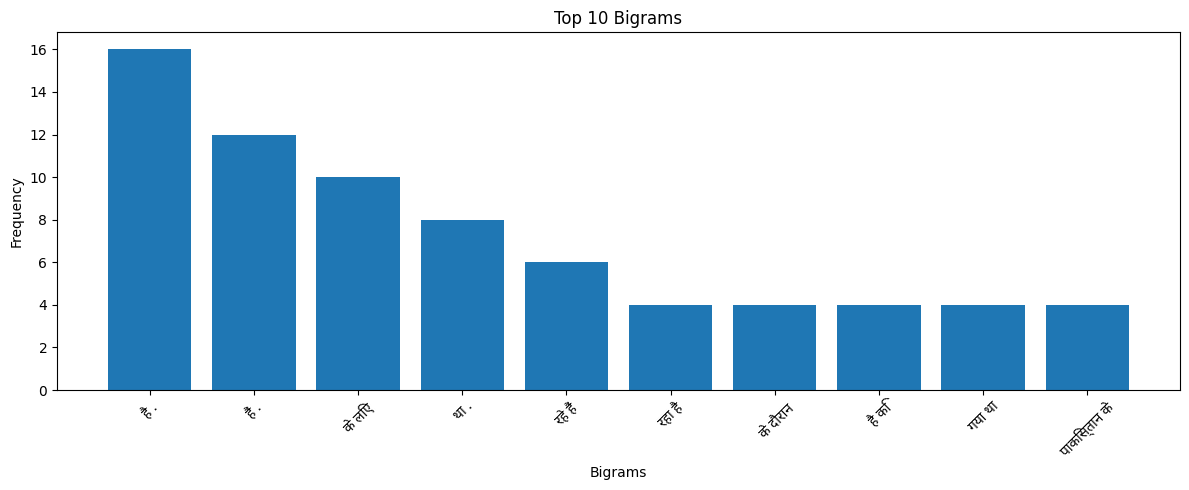

In [50]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Path of the Hindi/Devanagari font
font_path = "/usr/share/fonts/truetype/noto/NotoSansDevanagari-Regular.ttf"

# Create font properties
prop = fm.FontProperties(fname=font_path)

# Top 10 bigrams
top_bigrams = bigram_freq.most_common(10)

labels = [" ".join(bg) for bg, freq in top_bigrams]
counts = [freq for bg, freq in top_bigrams]

plt.figure(figsize=(12, 5))

plt.bar(labels, counts)

plt.title("Top 10 Bigrams")
plt.xlabel("Bigrams")
plt.ylabel("Frequency")

# Apply Devanagari font to Hindi bigram labels
plt.xticks(rotation=45, fontproperties=prop)

plt.tight_layout()
plt.show()